# SplitFed Demonstration Notebook

This notebook provides a simple interactive setup of the Split Federated Learning (SplitFed) simulator.
We will load the MNIST dataset, partition it among 3 simulated clients, and run a short training loop.

### Step 0: Remote Server Setup

If you are running this notebook on a remote Jupyter server (like Google Colab), run the following cell to clone the repository, install dependencies, and set the correct working directory.

In [1]:
import os, subprocess, sys
from pathlib import Path

repo_url = "https://github.com/tomal66/ad-sfl.git"
repo_path = Path("/content/ad-sfl")  # Colab workspace

def run(cmd, cwd=None):
    return subprocess.run(cmd, cwd=cwd, check=True, text=True, capture_output=True)

# 1) Clone if missing
if not repo_path.exists():
    subprocess.run(["git", "clone", repo_url, str(repo_path)], check=True)

# 2) Sanity check: must be a git repo now
if not (repo_path / ".git").exists():
    raise RuntimeError(
        f"{repo_path} exists but is not a git repo (no .git). "
        f"Delete/rename that folder or choose a different repo_path."
    )

# 3) Update: fetch + reset to remote default branch
subprocess.run(["git", "fetch", "--all", "--prune"], cwd=repo_path, check=True)

default_ref = run(["git", "symbolic-ref", "refs/remotes/origin/HEAD"], cwd=repo_path).stdout.strip()
branch = "attack"  # e.g., main / master

subprocess.run(["git", "checkout", branch], cwd=repo_path, check=True)
subprocess.run(["git", "reset", "--hard", f"origin/{branch}"], cwd=repo_path, check=True)
subprocess.run(["git", "clean", "-fd"], cwd=repo_path, check=True)

# 4) Set cwd to repo folder
os.chdir(repo_path)
print("CWD:", os.getcwd())
print("Branch:", branch)
print("HEAD:", run(["git", "rev-parse", "HEAD"], cwd=repo_path).stdout.strip())

# 5) Install datasets (for huggingface) and other requirements
subprocess.run([sys.executable, "-m", "pip", "install", "datasets"], check=True)
req = repo_path / "requirements.txt"
if req.exists():
    subprocess.run([sys.executable, "-m", "pip", "install", "-r", str(req)], check=True)

CWD: /content/ad-sfl
Branch: attack
HEAD: 6fb8ae6bedd1511fc4cc9acbec152c6c3fe2f374


In [2]:
import torch
from src.data.datasets import get_datasets
from src.data.partition import partition_data_iid, partition_data_dirichlet
from src.models.split import ClientModel, ServerModel
from src.core.client import SplitFedClient
from src.core.server import SplitFedServer
from src.core.seed import set_seed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


### Step 1: Load and Partition Data

In [3]:
# --- HYPERPARAMETERS & REPRODUCIBILITY ---
num_clients = 10
batch_size = 64
learning_rate = 3e-3
PRETRAINED_WEIGHTS = None # Use "DEFAULT" or None

GLOBAL_SEED = 42
set_seed(GLOBAL_SEED)
DATASET = "MNIST"

# Non-IID Dirichlet alpha (smaller means more unbalanced)
DIRICHLET_ALPHA = 1

# --- ATTACK HYPERPARAMETERS ---
ATTACK_TYPE = 'pair_flip'    # Options: 'none', 'pair_flip', 'targeted', 'backdoor'
MALICIOUS_FRACTION = 0.5    # Fraction of malicious clients

# Define attack-specific parameters
ATTACK_KWARGS = {
    "backdoor_poison_fraction": 1.0,
    "backdoor_target_label": 0,
    "backdoor_source_labels": [1, 2, 3],
    "trigger_size": 3,
    "trigger_value_raw": 1.0,
    "trigger_pos": "br",
    "flip_fraction": 1.0,
    "label_pairs_to_flip": [(1, 8), (2, 7), (3, 9)]
}
# -----------------------------------------
# Hugging Face Token (if required for gated datasets like ImageNet)
HF_TOKEN = None

print(f"Loading {DATASET} dataset...")
train_data, test_data = get_datasets(dataset_name=DATASET, hf_token=HF_TOKEN)

print(f"Partitioning data into Non-IID subsets (Dirichlet alpha={DIRICHLET_ALPHA})...")
client_datasets = partition_data_dirichlet(train_data, num_clients, alpha=DIRICHLET_ALPHA)


Global seed set to: 42
Loading MNIST dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Partitioning data into Non-IID subsets (Dirichlet alpha=1)...


### Step 2: Initialize Server and Client Models

In SplitFed, a portion of the network is on the client, and the rest is on the server.

In [4]:
import copy
import numpy as np

from src.models.split import get_split_models
from src.data.poisoned_dataset import PoisonedDataset

base_client_model, server_model = get_split_models(DATASET, weights=PRETRAINED_WEIGHTS)
server = SplitFedServer(model=server_model, num_clients=num_clients, lr=learning_rate, device=device)

# Determine malicious clients
num_malicious = int(num_clients * MALICIOUS_FRACTION)
malicious_clients_indices = set(np.random.choice(num_clients, num_malicious, replace=False))

clients = []
for i in range(num_clients):
    client_model = copy.deepcopy(base_client_model)
    is_mal = i in malicious_clients_indices
    c_dataset = client_datasets[i]
    if is_mal and ATTACK_TYPE != 'none':
        c_dataset = PoisonedDataset(c_dataset, attack_type=ATTACK_TYPE,
                                    attack_kwargs=ATTACK_KWARGS, dataset_name=DATASET,
                                    seed=GLOBAL_SEED+i)
    client = SplitFedClient(client_id=i, model=client_model, dataset=c_dataset, 
                            batch_size=batch_size, lr=learning_rate, device=device,
                            is_malicious=is_mal)
    clients.append(client)

print(f"Initialized 1 Server and {num_clients} Clients.")
print(f"Injected '{ATTACK_TYPE}' into {len(malicious_clients_indices)} malicious clients: {malicious_clients_indices}")


Initialized 1 Server and 10 Clients.
Injected 'pair_flip' into 5 malicious clients: {np.int64(1), np.int64(4), np.int64(5), np.int64(7), np.int64(9)}


In [5]:
import torch
from collections import OrderedDict

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable = total - trainable
    return {"total": total, "trainable": trainable, "non_trainable": non_trainable}

def format_counts(title, d):
    return f"{title}: total={d['total']:,} | trainable={d['trainable']:,} | non-trainable={d['non_trainable']:,}"

# --- client / server ---
client_counts = count_params(base_client_model)
server_counts = count_params(server_model)

# --- combined (client + server) ---
# safest: sum counts (no risk of name collisions)
combined_counts = {
    "total": client_counts["total"] + server_counts["total"],
    "trainable": client_counts["trainable"] + server_counts["trainable"],
    "non_trainable": client_counts["non_trainable"] + server_counts["non_trainable"],
}

print(format_counts("CLIENT", client_counts))
print(format_counts("SERVER", server_counts))
print(format_counts("COMBINED", combined_counts))

CLIENT: total=320 | trainable=320 | non-trainable=0
SERVER: total=421,322 | trainable=421,322 | non-trainable=0
COMBINED: total=421,642 | trainable=421,642 | non-trainable=0


### Step 3: Simulation Loop

In [6]:
import matplotlib.pyplot as plt
from tqdm.auto import trange
from torch.utils.data import DataLoader
from src.algorithms import run_sfl_round
from src.algorithms.evaluate import (
    evaluate_accuracy, 
    evaluate_backdoor_asr, 
    evaluate_targeted_asr, 
    evaluate_pair_flip_asr
)

rounds = 50
historical_train_acc = []
historical_test_acc = []
historical_asr = []

test_loader = DataLoader(
    test_data, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True
)

pbar = trange(rounds, desc="Training", unit="round")
for r in pbar:
    train_loss, train_acc = run_sfl_round(clients, server, local_epochs=1)
    
    # Evaluate Test Acc and ASR
    eval_client = clients[0].model
    test_acc = evaluate_accuracy(eval_client, server.model, test_loader, device)
    
    asr = 0.0
    if ATTACK_TYPE == 'backdoor':
        asr = evaluate_backdoor_asr(eval_client, server.model, test_loader, 
                                    ATTACK_KWARGS.get('backdoor_source_labels', []), 
                                    ATTACK_KWARGS.get('backdoor_target_label', 0), 
                                    ATTACK_KWARGS, device)
    elif ATTACK_TYPE == 'targeted':
        asr = evaluate_targeted_asr(eval_client, server.model, test_loader, 
                                    ATTACK_KWARGS.get('targeted_source_labels', []), 
                                    ATTACK_KWARGS.get('targeted_target_label', 0), 
                                    device)
    elif ATTACK_TYPE == 'pair_flip':
        asr = evaluate_pair_flip_asr(eval_client, server.model, test_loader, 
                                     ATTACK_KWARGS.get('label_pairs_to_flip', []), 
                                     device)
    
    historical_train_acc.append(train_acc)
    historical_test_acc.append(test_acc)
    historical_asr.append(asr)
    
    pbar.set_postfix(loss=f"{train_loss:.4f}", test_acc=f"{test_acc:.4f}", asr=f"{asr:.4f}")



Training:   0%|          | 0/50 [00:00<?, ?round/s]

Training simulation complete. Plotting accuracy...


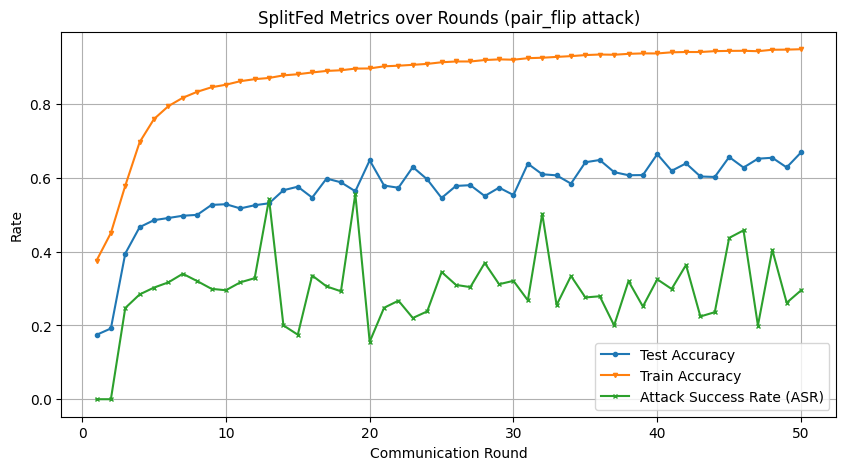

In [7]:
print("Training simulation complete. Plotting accuracy...")
plt.figure(figsize=(10, 5))
plt.plot(range(1, rounds + 1), historical_test_acc, marker="o", markersize=3, label="Test Accuracy")
plt.plot(range(1, rounds + 1), historical_train_acc, marker="v", markersize=3, label="Train Accuracy")
plt.plot(range(1, rounds + 1), historical_asr, marker="x", markersize=3, label="Attack Success Rate (ASR)")
plt.title(f"SplitFed Metrics over Rounds ({ATTACK_TYPE} attack)")
plt.xlabel("Communication Round")
plt.ylabel("Rate")
plt.legend()
plt.grid(True)
plt.show()


### Step 4: SFL Gold Evaluation (Oracle)

Optionally, you can run the `sfl_gold` algorithm which completely ignores malicious clients during training and aggregation, establishing an upper bound performance.

In [8]:
import matplotlib.pyplot as plt
from tqdm.auto import trange
from torch.utils.data import DataLoader
from src.algorithms import run_sfl_gold_round
from src.algorithms.evaluate import (
    evaluate_accuracy, 
    evaluate_backdoor_asr, 
    evaluate_targeted_asr, 
    evaluate_pair_flip_asr
)

rounds = 50
gold_historical_train_acc = []
gold_historical_test_acc = []
gold_historical_asr = []

test_loader = DataLoader(
    test_data, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True
)

# Re-initialize models for Gold baseline
print('Re-initializing models for Gold...')
base_client_model, server_model = get_split_models(DATASET, weights=PRETRAINED_WEIGHTS)
server = SplitFedServer(model=server_model, num_clients=num_clients, lr=learning_rate, device=device)
clients = []
for i in range(num_clients):
    client_model = copy.deepcopy(base_client_model)
    is_mal = i in malicious_clients_indices
    c_dataset = client_datasets[i]
    if is_mal and ATTACK_TYPE != 'none':
        c_dataset = PoisonedDataset(c_dataset, attack_type=ATTACK_TYPE, attack_kwargs=ATTACK_KWARGS, dataset_name=DATASET, seed=GLOBAL_SEED+i)
    client = SplitFedClient(client_id=i, model=client_model, dataset=c_dataset, batch_size=batch_size, lr=learning_rate, device=device, is_malicious=is_mal)
    clients.append(client)

pbar = trange(rounds, desc="Training", unit="round")
for r in pbar:
    train_loss, train_acc = run_sfl_gold_round(clients, server, local_epochs=1)
    
    # Evaluate Test Acc and ASR
    eval_client = clients[0].model
    test_acc = evaluate_accuracy(eval_client, server.model, test_loader, device)
    
    asr = 0.0
    if ATTACK_TYPE == 'backdoor':
        asr = evaluate_backdoor_asr(eval_client, server.model, test_loader, 
                                    ATTACK_KWARGS.get('backdoor_source_labels', []), 
                                    ATTACK_KWARGS.get('backdoor_target_label', 0), 
                                    ATTACK_KWARGS, device)
    elif ATTACK_TYPE == 'targeted':
        asr = evaluate_targeted_asr(eval_client, server.model, test_loader, 
                                    ATTACK_KWARGS.get('targeted_source_labels', []), 
                                    ATTACK_KWARGS.get('targeted_target_label', 0), 
                                    device)
    elif ATTACK_TYPE == 'pair_flip':
        asr = evaluate_pair_flip_asr(eval_client, server.model, test_loader, 
                                     ATTACK_KWARGS.get('label_pairs_to_flip', []), 
                                     device)
    
    gold_historical_train_acc.append(train_acc)
    gold_historical_test_acc.append(test_acc)
    gold_historical_asr.append(asr)
    
    pbar.set_postfix(loss=f"{train_loss:.4f}", test_acc=f"{test_acc:.4f}", asr=f"{asr:.4f}")



Re-initializing models for Gold...


Training:   0%|          | 0/50 [00:00<?, ?round/s]

Training simulation complete. Plotting accuracy...


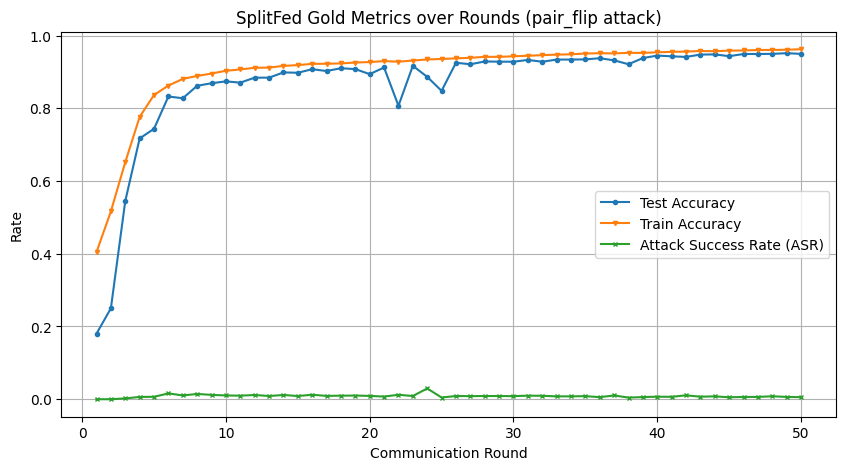

In [9]:
print("Training simulation complete. Plotting accuracy...")
plt.figure(figsize=(10, 5))
plt.plot(range(1, rounds + 1), gold_historical_test_acc, marker="o", markersize=3, label="Test Accuracy")
plt.plot(range(1, rounds + 1), gold_historical_train_acc, marker="v", markersize=3, label="Train Accuracy")
plt.plot(range(1, rounds + 1), gold_historical_asr, marker="x", markersize=3, label="Attack Success Rate (ASR)")
plt.title(f"SplitFed Gold Metrics over Rounds ({ATTACK_TYPE} attack)")
plt.xlabel("Communication Round")
plt.ylabel("Rate")
plt.legend()
plt.grid(True)
plt.show()


### Step 5: Centinel Evaluation

This section evaluates the Centinel defense method, which uses anomaly detection on activation centroids and Subjective Logic to build client reputations over time.

In [ ]:
from src.algorithms.centinel import run_sfl_centinel_round, CentinelState
from torch.utils.data import Subset
import numpy as np
from torch.utils.data import DataLoader


# --- Centinel Hyperparameters ---
NUM_REF_SAMPLES_PER_LABEL = 10
TAU = 0.1
OMEGA = 0.7
Q_i = 0.8
rho = 0.4
eta = 0.6
kappa = 0.7
zeta = 0.3

# Build a small, class-balanced reference dataset from the test set
labels = np.array(test_data.hf_dataset[test_data.label_key])
ref_indices = []
num_classes = len(np.unique(labels))
for c in range(num_classes):
    c_indices = np.where(labels == c)[0]
    ref_indices.extend([int(x) for x in np.random.choice(c_indices, NUM_REF_SAMPLES_PER_LABEL, replace=False)])

ref_dataset = Subset(test_data, ref_indices)
ref_loader = DataLoader(ref_dataset, batch_size=batch_size, shuffle=False)

state = CentinelState(num_clients, tau=TAU, omega=OMEGA, Q_i=Q_i, rho=rho, eta=eta, kappa=kappa, zeta=zeta)

# Quick initial centroids generation using client 0
print("Re-initializing models for Centinel...")
base_client_model, server_model = get_split_models(DATASET, weights=PRETRAINED_WEIGHTS)
server = SplitFedServer(model=server_model, num_clients=num_clients, lr=learning_rate, device=device)
clients = []
for i in range(num_clients):
    client_model = copy.deepcopy(base_client_model)
    is_mal = i in malicious_clients_indices
    c_dataset = client_datasets[i]
    if is_mal and ATTACK_TYPE != 'none':
        c_dataset = PoisonedDataset(c_dataset, attack_type=ATTACK_TYPE, attack_kwargs=ATTACK_KWARGS, dataset_name=DATASET, seed=GLOBAL_SEED+i)
    client = SplitFedClient(client_id=i, model=client_model, dataset=c_dataset, batch_size=batch_size, lr=learning_rate, device=device, is_malicious=is_mal)
    clients.append(client)

from src.algorithms.centinel import compute_centroids
client0 = clients[0]
client0.model.eval()
with torch.no_grad():
    for data, target in ref_loader:
        acts = client0.model(data.to(device))
        c, counts = compute_centroids(acts, target.to(device))
        for lbl in c:
            if lbl in state.global_centroids:
                state.global_centroids[lbl] = (state.global_centroids[lbl] + c[lbl])/2
            else:
                state.global_centroids[lbl] = c[lbl]


Re-initializing models for Centinel...


In [ ]:
import matplotlib.pyplot as plt
from tqdm.auto import trange
from torch.utils.data import DataLoader
from src.algorithms import run_sfl_gold_round
from src.algorithms.evaluate import (
    evaluate_accuracy, 
    evaluate_backdoor_asr, 
    evaluate_targeted_asr, 
    evaluate_pair_flip_asr
)

rounds = 50
centinel_historical_train_acc = []
centinel_historical_test_acc = []
centinel_historical_asr = []

test_loader = DataLoader(
    test_data, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True
)

pbar = trange(rounds, desc="Training", unit="round")
for r in pbar:
    train_loss, train_acc, scores, accepted_clients = run_sfl_centinel_round(clients, server, state, ref_loader, local_epochs=1, device=device)
    
    # Evaluate Test Acc and ASR
    eval_client = clients[0].model
    test_acc = evaluate_accuracy(eval_client, server.model, test_loader, device)
    
    asr = 0.0
    if ATTACK_TYPE == 'backdoor':
        asr = evaluate_backdoor_asr(eval_client, server.model, test_loader, 
                                    ATTACK_KWARGS.get('backdoor_source_labels', []), 
                                    ATTACK_KWARGS.get('backdoor_target_label', 0), 
                                    ATTACK_KWARGS, device)
    elif ATTACK_TYPE == 'targeted':
        asr = evaluate_targeted_asr(eval_client, server.model, test_loader, 
                                    ATTACK_KWARGS.get('targeted_source_labels', []), 
                                    ATTACK_KWARGS.get('targeted_target_label', 0), 
                                    device)
    elif ATTACK_TYPE == 'pair_flip':
        asr = evaluate_pair_flip_asr(eval_client, server.model, test_loader, 
                                     ATTACK_KWARGS.get('label_pairs_to_flip', []), 
                                     device)
    
    centinel_historical_train_acc.append(train_acc)
    centinel_historical_test_acc.append(test_acc)
    centinel_historical_asr.append(asr)
    
    pbar.set_postfix(loss=f"{train_loss:.4f}", test_acc=f"{test_acc:.4f}", asr=f"{asr:.4f}")



In [ ]:
print("Training simulation complete. Plotting accuracy...")
plt.figure(figsize=(10, 5))
plt.plot(range(1, rounds + 1), centinel_historical_test_acc, marker="o", markersize=3, label="Test Accuracy")
plt.plot(range(1, rounds + 1), centinel_historical_train_acc, marker="v", markersize=3, label="Train Accuracy")
plt.plot(range(1, rounds + 1), centinel_historical_asr, marker="x", markersize=3, label="Attack Success Rate (ASR)")
plt.title(f"SplitFed Centinel Metrics over Rounds ({ATTACK_TYPE} attack)")
plt.xlabel("Communication Round")
plt.ylabel("Rate")
plt.legend()
plt.grid(True)
plt.show()
